In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

suvinathapa_movie_review_dataset_path = kagglehub.dataset_download('suvinathapa/movie-review-dataset')
suvinathapa_saved_model_path = kagglehub.dataset_download('suvinathapa/saved-model')

print('Data source import complete.')


Task3 : Sentiment Analysis : Text Classification with RNN and LSTM

**Module:** 6CS012 Final Portfolio Project
**Student:** Suvina Thapa

In [ ]:
import requests
print(requests.get("https://pypi.org").status_code)

200


In [ ]:
!pip install contractions

In [ ]:
#Installing Dependencies and Library
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *pkgs])

pip_install("gradio", "contractions", "wordcloud", "gensim")

print("✓ Extra packages installed")

✓ Extra packages installed


In [ ]:
#LIbrary
import os, re, pickle, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

#NLP
import nltk
nltk.download("stopwords",    quiet=True)
nltk.download("wordnet",      quiet=True)
nltk.download("omw-1.4",      quiet=True)
nltk.download("punkt",        quiet=True)

from nltk.corpus   import stopwords
from nltk.stem     import WordNetLemmatizer
import contractions
from wordcloud import WordCloud

#Word2Vec
from gensim.models import Word2Vec

#Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (accuracy_score, confusion_matrix,classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing   import LabelEncoder

#Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models                 import Sequential
from tensorflow.keras.layers                 import (Embedding, SimpleRNN, LSTM,
                                                       Dense, Dropout)
from tensorflow.keras.callbacks              import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils                  import to_categorical

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

#Global PLot
BG = "#F8FAFC"
PALETTE = ["#2563EB", "#DC2626", "#059669", "#F59E0B", "#7C3AED"]
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.facecolor": BG, "axes.facecolor": BG})

#Output Directory
SAVE_DIR = "/kaggle/working/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"✓ TensorFlow {tf.__version__}  |  All libraries loaded")
print(f"✓ Models will be saved to: {SAVE_DIR}")

✓ TensorFlow 2.19.0  |  All libraries loaded
✓ Models will be saved to: /kaggle/working/saved_models


#Dataset Loading


In [ ]:
#Loading Dataset
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/suvinathapa/saved-model/saved_models/label_encoder.pkl
/kaggle/input/datasets/suvinathapa/saved-model/saved_models/LSTM_Word2Vec_Embedding_best.keras
/kaggle/input/datasets/suvinathapa/saved-model/saved_models/model1_SimpleRNN_final.keras
/kaggle/input/datasets/suvinathapa/saved-model/saved_models/LSTM_Trainable_Embedding_best.keras
/kaggle/input/datasets/suvinathapa/saved-model/saved_models/model3_LSTM_word2vec_final.keras
/kaggle/input/datasets/suvinathapa/saved-model/saved_models/model2_LSTM_trainable_final.keras
/kaggle/input/datasets/suvinathapa/saved-model/saved_models/SimpleRNN_Model_best.keras
/kaggle/input/datasets/suvinathapa/saved-model/saved_models/config.pkl
/kaggle/input/datasets/suvinathapa/saved-model/saved_models/tokenizer.pkl
/kaggle/input/datasets/suvinathapa/movie-review-dataset/Movie Review Dataset/5. Movie Review Dataset/val_movie_review.csv
/kaggle/input/datasets/suvinathapa/movie-review-dataset/Movie Review Dataset/5. Movie Review Dataset/

In [ ]:
import pandas as pd
import os

# Load all three splits and combine
DATA_DIR   = '/kaggle/input/datasets/suvinathapa/movie-review-dataset/Movie Review Dataset/5. Movie Review Dataset'

train_df   = pd.read_csv(DATA_DIR + '/train_movie_review.csv')
val_df     = pd.read_csv(DATA_DIR + '/val_movie_review.csv')
test_df    = pd.read_csv(DATA_DIR + '/test_movie_review.csv')

# Combine all into one dataframe
df_raw     = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f'Train rows : {len(train_df):,}')
print(f'Val rows   : {len(val_df):,}')
print(f'Test rows  : {len(test_df):,}')
print(f'Combined   : {len(df_raw):,}')
print()

# Auto-detect text & label columns
TEXT_KEYWORDS  = ["text", "tweet", "sentence", "review", "comment", "content"]
LABEL_KEYWORDS = ["label", "sentiment", "target", "class", "category", "emotion"]

def detect_col(df, keywords):
    for kw in keywords:
        for col in df.columns:
            if kw in col.lower():
                return col
    return df.columns[-1]

TEXT_COL  = detect_col(df_raw, TEXT_KEYWORDS)
LABEL_COL = detect_col(df_raw, LABEL_KEYWORDS)

print(f"Detected text  column : '{TEXT_COL}'")
print(f"Detected label column : '{LABEL_COL}'")
print(f"Dataset shape         : {df_raw.shape}")
display(df_raw.head())

Train rows : 35,000
Val rows   : 5,000
Test rows  : 10,000
Combined   : 50,000

Detected text  column : 'review'
Detected label column : 'sentiment'
Dataset shape         : (50000, 3)


,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not...",0
1,48396,With this movie I was really hoping that the idea was to make up for the hashed together ineptitude of the first AVP...,0
2,1980,Raymond Burr stars as an attorney caught up in the murder of his best friend (Dick Foran) thanks to his affection fo...,0
3,6703,"A lot people get hung up on this films tag as a ""children's film"", and that it certainly is, though it is one made f...",1
4,28168,I was a fan of Buffy and hoped it would come to a proper end when Angel got only one more season. But when the end c...,0


In [ ]:
#Basic Overview
print("Data Types")
display(df_raw.dtypes.to_frame("dtype").T)

print("\nMissing Values")
display(df_raw.isnull().sum().to_frame("Missing").T)

print("\nClass Distribution")
display(df_raw[LABEL_COL].value_counts().to_frame("Count"))

Data Types


,Unnamed: 0,review,sentiment
dtype,int64,object,int64



Missing Values


,Unnamed: 0,review,sentiment
Missing,0,0,0



Class Distribution


,Count
sentiment,
0,25000
1,25000


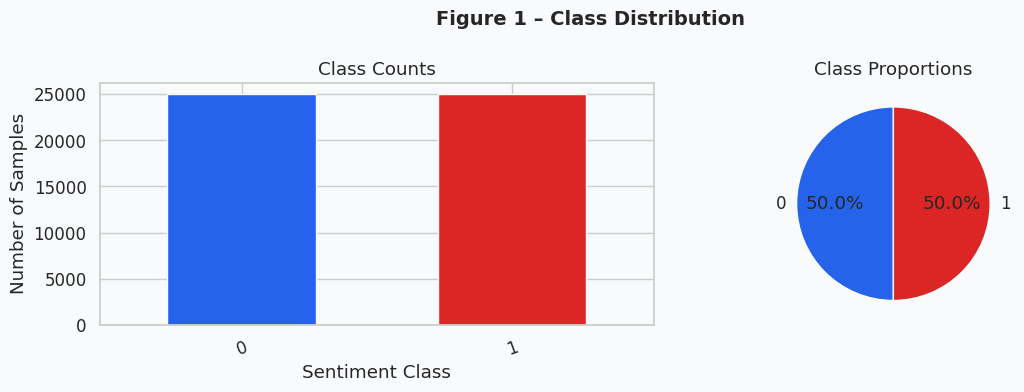

In [ ]:
# Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = df_raw[LABEL_COL].value_counts()

vc.plot(kind='bar', ax=axes[0],
        color=PALETTE[:len(vc)], edgecolor='white', width=0.55)
axes[0].set_title("Class Counts")
axes[0].set_xlabel("Sentiment Class")
axes[0].set_ylabel("Number of Samples")
axes[0].tick_params(axis='x', rotation=20)

vc.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
        colors=PALETTE[:len(vc)], startangle=90)
axes[1].set_ylabel("")
axes[1].set_title("Class Proportions")

plt.suptitle("Figure 1 – Class Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation (Figure 1):**  
The class distribution shows whether the dataset is balanced or imbalanced across sentiment categories.  
A balanced dataset ensures the model does not develop a bias towards a majority class.  
If significant imbalance exists, class-weighted training or oversampling techniques such as SMOTE should be considered.  
The pie chart confirms the proportional split, which informs our choice of loss function and evaluation metrics.

**#Text Processing, Tokenisation And Sequence padding**
-> pirpeline apllied:
1.expanding contraction like don't to do not
2. lowercase
3. removing urls, mention, hastags, number na dspecial characters
4.removing stopwords
5. Lemmatise

In [ ]:
STOP_WORDS  = set(stopwords.words("english"))
lemmatizer  = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Full cleaning pipeline for a single tweet."""
    if pd.isna(text):
        return ""
    text = str(text)
     # strip HTML tags like <br>, <p>, <i> etc. ──
    text = re.sub(r"<[^>]+>", " ", text)
    # 1. Expand contractions  (don't → do not)
    text = contractions.fix(text)
    # 2. Lowercase
    text = text.lower()
    # 3. Removing URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    # 4. Removing @mentions
    text = re.sub(r"@\w+", "", text)
    # 5. Removing #hashtags (keep the word, drop the #)
    text = re.sub(r"#(\w+)", r"\1", text)
    # 6. Removing numbers and special characters
    text = re.sub(r"[^a-z\s]", " ", text)
    # 7. Tokenise by whitespace
    tokens = text.split()
    # 8. Remove stopwords and lemmatise
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)

# Apply cleaning to full combined dataset
df = df_raw[[TEXT_COL, LABEL_COL]].dropna().copy()
df.rename(columns={TEXT_COL: "text_raw", LABEL_COL: "label"}, inplace=True)
df["text_clean"] = df["text_raw"].apply(clean_text)

# Drop rows where cleaning produced empty string
df = df[df["text_clean"].str.strip().ne("")]
df.reset_index(drop=True, inplace=True)

print(f"Rows after cleaning: {len(df):,}")

Rows after cleaning: 50,000


In [ ]:
#Before vs After cleaning table orandom 8 exmaple of raw vs fuly cleaned

sample_idx   = df.sample(8, random_state=SEED).index
before_after = df.loc[sample_idx, ["text_raw", "text_clean"]].copy()
before_after.columns = ["Raw Tweet", "Cleaned Tweet"]
before_after.reset_index(drop=True, inplace=True)

# Style: truncate long cells for readability
pd.set_option("display.max_colwidth", 120)
print("Before vs After Cleaning:")
display(before_after)

Before vs After Cleaning:


,Raw Tweet,Cleaned Tweet
0,"If there was a ZERO rating, I would give it to this movie. Today was the second time I tried to watch it and I still...",zero rating would give movie today second time tried watch still could make beginning end cannot believe multiple st...
1,I had the misfortune to watch this rubbish on Sky Cinema Max in a cold winter night. I am not a big fan of horror mo...,misfortune watch rubbish sky cinema max cold winter night big fan horror movie trash one even worse one dumbest piec...
2,This is a perfect movie to watch with a loved one on a cold and snowy night. If you like a few laughs with your horr...,perfect movie watch loved one cold snowy night like laugh horror movie making real cult classic everything would wan...
3,This movie is a bad to alright rip off of Friday the 13th. The movie is about a killer named Bernie who kills people...,movie bad alright rip friday th movie killer named bernie kill people around camp councilor training camp kill peopl...
4,"This was my second time watching the film (via the French-language version as opposed to the first, which was dubbed...",second time watching film via french language version opposed first dubbed italian feel improves subsequent viewing ...
5,"Yes, why? Among the filmmakers that came out in the 80's and 90's Gus Van Sant is one of my idols. There are others,...",yes among filmmaker came gu van sant one idol others steven sodebergh pt anderson tim hunter danny boyle martin dono...
6,Remember that friend in college who always insisted you rent the weirdest movie possible? This is the movie he would...,remember friend college always insisted rent weirdest movie possible movie would made would chance wish could tell e...
7,I saw this film a few years ago and I got to say that I really love it.Jason Patric was perfect for this weird role ...,saw film year ago got say really love jason patric perfect weird role played director many thing care screenplay goo...


In [ ]:
#encoding labels to int
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])
NUM_CLASSES = len(le.classes_)

print(f"Classes ({NUM_CLASSES}): {list(le.classes_)}")
print(f"Encoding map: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Classes (2): [np.int64(0), np.int64(1)]
Encoding map: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


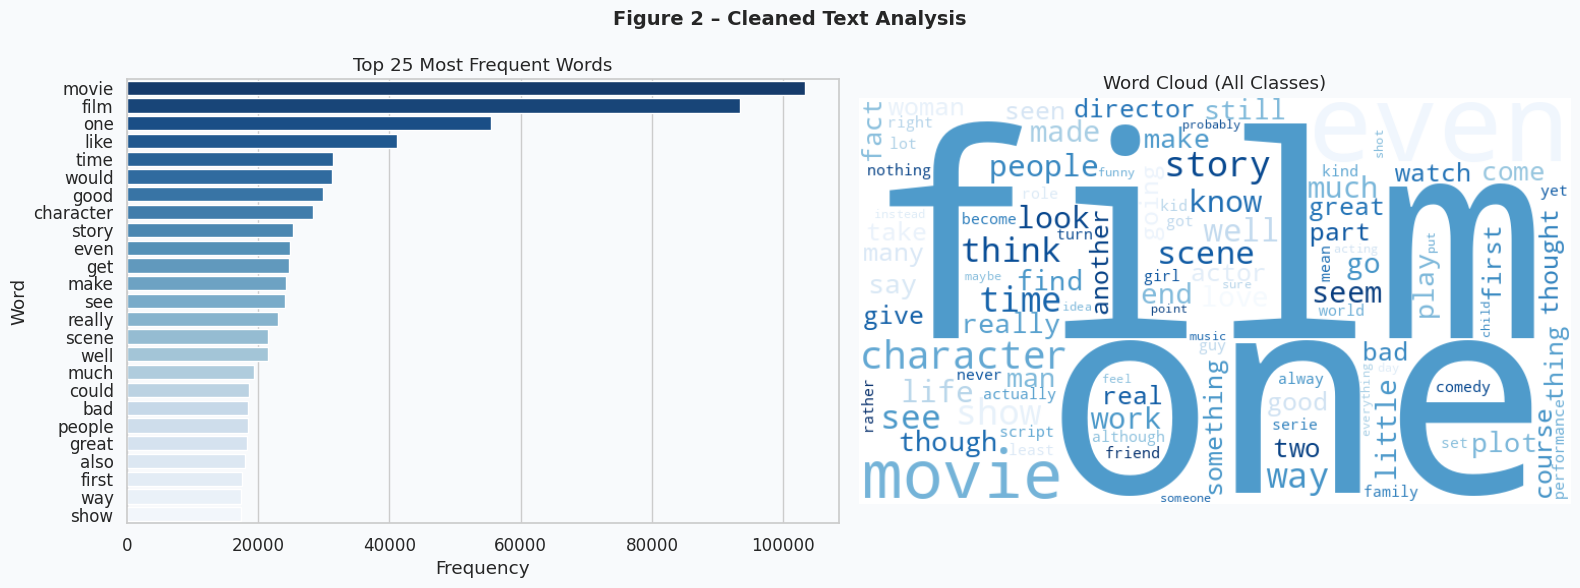

In [ ]:
#Analysis word frequency Analysis
from collections import Counter

all_words   = " ".join(df["text_clean"]).split()
freq        = Counter(all_words)
top_words   = pd.DataFrame(freq.most_common(25), columns=["Word", "Frequency"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart for top 25 frequent words
sns.barplot(x="Frequency", y="Word", data=top_words, ax=axes[0],
            hue="Word", palette="Blues_r", legend=False)
axes[0].set_title("Top 25 Most Frequent Words")
axes[0].set_xlabel("Frequency")

# Word cloud
wc = WordCloud(width=700, height=400, background_color="white",
               colormap="Blues", max_words=100).generate(" ".join(all_words))
axes[1].imshow(wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud (All Classes)")

plt.suptitle("Figure 2 – Cleaned Text Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

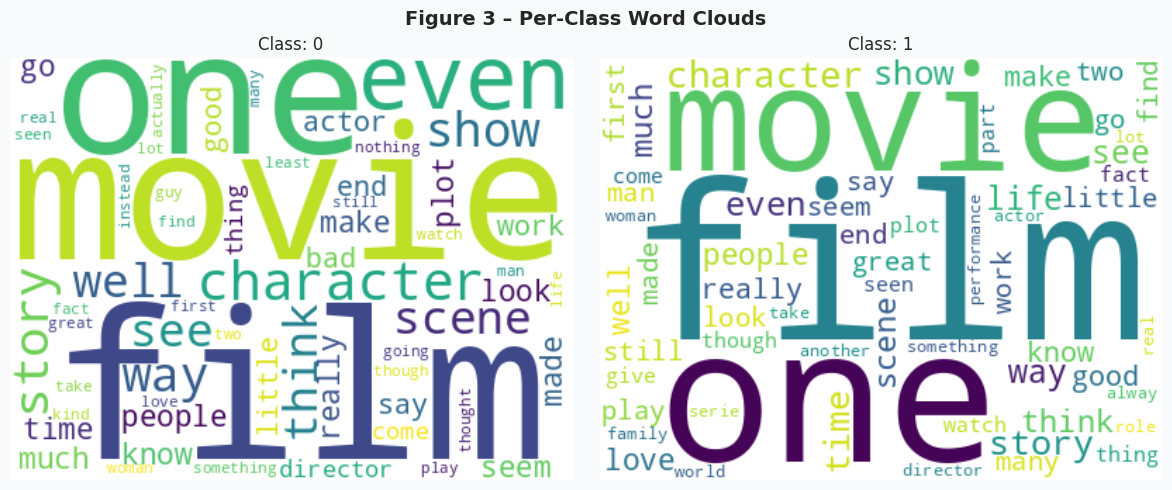

In [ ]:
#Per class word
n_classes = NUM_CLASSES
fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5))
if n_classes == 1:
    axes = [axes]

for ax, cls in zip(axes, le.classes_):
    subset = df[df["label"] == cls]["text_clean"]
    text   = " ".join(subset)
    if not text.strip():
        ax.axis("off"); continue
    wc = WordCloud(width=400, height=300, background_color="white",
                   colormap="viridis", max_words=60).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Class: {cls}", fontsize=12)

plt.suptitle("Figure 3 – Per-Class Word Clouds", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Figure 2 shows the most frequent tokens after cleaning. Domain-specific words related to movies (e.g. *film*, *story*, *character*) dominate, which is expected for this dataset.  
Figure 3 separates word usage by class: positive reviews tend to contain words like *great*, *love*, *best*, while negative reviews contain *bad*, *worst*, *boring*. This clear lexical separation suggests the dataset contains learnable sentiment signal, which should allow the RNN/LSTM models to distinguish between classes effectively.

In [ ]:
#TRaning and test splitting then tokenisation then padding where we keep X_raw orginal text along with X cleaned so we cna displaythe original tet during eror analysis
X_raw   = df["text_raw"].values
X       = df["text_clean"].values
y       = df["label_enc"].values

X_train_raw, X_test_raw, X_train, X_test, y_train, y_test = train_test_split(
    X_raw, X, y,
    test_size=0.2,
    random_state=SEED,
    #Ensure same ckass proportion in both split
    stratify=y)

print(f"Train samples : {len(X_train):,}")
print(f"Test  samples : {len(X_test):,}")

Train samples : 40,000
Test  samples : 10,000


In [ ]:
#Keras Tokenizer
#how many unique token the model tracks
VOCAB_SIZE = 20_000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
#fitting on training only no leakge
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

actual_vocab = len(tokenizer.word_index)
print(f"Vocabulary size (total) : {actual_vocab:,}")
print(f"Vocabulary size (capped): {VOCAB_SIZE:,}")
print(f"Sample sequence         : {X_train_seq[0][:15]} …")

Vocabulary size (total) : 81,742
Vocabulary size (capped): 20,000
Sample sequence         : [455, 694, 1251, 14948, 1, 18083, 18740, 487, 5731, 1503, 385, 2986, 472, 3473, 242] …


Sequence length stats (train):
  Min    : 3
  Mean   : 118.4
  Median : 88.0
  95th % : 307  ← used as MAX_LEN
  Max    : 1406


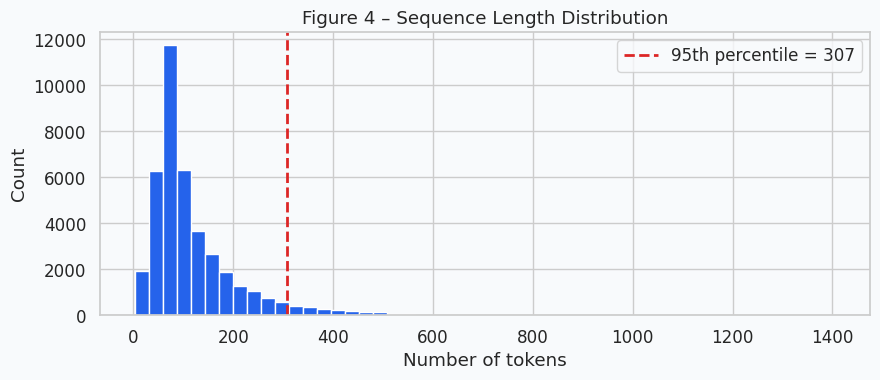

In [ ]:
#Padding based on percentile
#using 95 to avoid padding the length of outlier long twwet
lengths    = [len(s) for s in X_train_seq]
MAX_LEN    = int(np.percentile(lengths, 95))

print(f"Sequence length stats (train):")
print(f"  Min    : {min(lengths)}")
print(f"  Mean   : {np.mean(lengths):.1f}")
print(f"  Median : {np.median(lengths):.1f}")
print(f"  95th % : {MAX_LEN}  ← used as MAX_LEN")
print(f"  Max    : {max(lengths)}")

# Distribution plot
plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=50, color="#2563EB", edgecolor="white")
plt.axvline(MAX_LEN, color="#DC2626", linestyle="--", linewidth=2,
            label=f"95th percentile = {MAX_LEN}")
plt.title("Figure 4 – Sequence Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

**Observation (Figure 4):**  
The sequence length distribution is right-skewed, meaning most reviews are short but a few are very long. The 95th percentile is at 307 tokens, so 95% of all reviews fall within this length. This is why 307 was chosen as MAX_LEN as it covers almost all reviews without wasting memory on extreme outliers. If the maximum length of ~1406 was used instead, every review would be padded to 4× the necessary length, making training much slower for no real improvement. Any review longer than 307 tokens is cut off from the end (truncating='post'), which is acceptable since most of the important sentiment information appears early in the review.

In [ ]:
#Applying padding to train and test
#padding post append zero at the end
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

print(f"X_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")

# one-hot for multi-class, raw for binary  and configuring loss function and out layer based on number of class
if NUM_CLASSES == 2:
    y_train_cat = y_train
    y_test_cat  = y_test
    LOSS        = "binary_crossentropy"
    OUT_UNITS   = 1
    OUT_ACT     = "sigmoid"
else:
    y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
    y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)
    LOSS        = "categorical_crossentropy"
    OUT_UNITS   = NUM_CLASSES
    OUT_ACT     = "softmax"

print(f"\nTask type  : {'Binary' if NUM_CLASSES==2 else 'Multi-class'}")
print(f"Loss       : {LOSS}")
print(f"Output dim : {OUT_UNITS}")
print(f"Output activation : {OUT_ACT}")

X_train_pad shape : (40000, 307)
X_test_pad  shape : (10000, 307)

Task type  : Binary
Loss       : binary_crossentropy
Output dim : 1
Output activation : sigmoid


**Model Building And Training**

In [ ]:
# ── Shared training hyperparameters ──────────────────────────────────────
EMBED_DIM  = 128
EPOCHS     = 30
BATCH_SIZE = 64

# ── Shared callbacks (recreated fresh per model) ──────────────────────────
def get_callbacks(model_name):
    """Return fresh callback instances for each model to avoid state bleed."""
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=4,
        # resets weights to best checkpoint on stop
        restore_best_weights=True,
        verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
         # halve the learning rate
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=0
    )
    checkpoint = ModelCheckpoint(
        filepath=f"{SAVE_DIR}/{model_name}_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=0
    )
    return [early_stop, reduce_lr, checkpoint]

# Storage dictionaries for later comparison and evaluation
histories   = {}
eval_models = {}

print(f"EMBED_DIM  = {EMBED_DIM}")
print(f"VOCAB_SIZE = {VOCAB_SIZE}")
print(f"MAX_LEN    = {MAX_LEN}")
print(f"NUM_CLASSES= {NUM_CLASSES}")
print(f"EPOCHS     = {EPOCHS}")
print(f"BATCH_SIZE = {BATCH_SIZE}")

EMBED_DIM  = 128
VOCAB_SIZE = 20000
MAX_LEN    = 307
NUM_CLASSES= 2
EPOCHS     = 30
BATCH_SIZE = 64


In [ ]:
#Model 1 with simple RNN with traning Embedding
from tensorflow.keras.layers import Input
tf.keras.backend.clear_session()

model1 = Sequential([
    Input(shape=(MAX_LEN,)),
    #  converts integer token IDs to dense vectors
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    #process 64 sequence and output single vector
    SimpleRNN(units=64, return_sequences=False),
    Dropout(0.4),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(OUT_UNITS, activation=OUT_ACT),
], name="SimpleRNN_Model")

model1.compile(optimizer="adam", loss=LOSS, metrics=["accuracy"])
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 307, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,574,465 (9.82 MB)

 Trainable params: 2,574,465 (9.82 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

print("Training Model 1 – Simple RNN …")
history1 = model1.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=get_callbacks("SimpleRNN_Model"),
    verbose=1
)

# Save final weights too
model1.save(f"{SAVE_DIR}/model1_SimpleRNN_final.keras")
histories["Simple RNN"]  = history1
eval_models["Simple RNN"] = model1
print(f"✓ Model 1 saved to {SAVE_DIR}/model1_SimpleRNN_final.keras")

# 1. Extract the best accuracies
best_train_acc3 = max(history1.history['accuracy'])
best_val_acc3   = max(history1.history['val_accuracy'])

# 2. Print the results
print(f"Model 1 Best Training Accuracy:   {best_train_acc3:.4f}")
print(f"Model 1 Best Validation Accuracy: {best_val_acc3:.4f}")


Training Model 1 – Simple RNN …
Epoch 1/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.5028 - loss: 0.6986 - val_accuracy: 0.5042 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 2/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5014 - loss: 0.6936 - val_accuracy: 0.5030 - val_loss: 0.6947 - learning_rate: 0.0010
Epoch 3/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5050 - loss: 0.6957 - val_accuracy: 0.4895 - val_loss: 0.6964 - learning_rate: 0.0010
Epoch 4/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.4943 - loss: 0.7001 - val_accuracy: 0.5067 - val_loss: 0.6932 - learning_rate: 5.0000e-04
Epoch 5/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5074 - loss: 0.6939 - val_accuracy: 0.5033 - val_loss: 0.6937 - learning_rate: 5.0000e-04
Epoch 6/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5005 - loss: 0.6937 - val_accuracy: 0.5058 - val_loss: 0.6929 - learning_rate: 5.0000e-04
Epoch 7/30
563/563 ━━━━━━━━━━━━━

**MOdel 2 -LSTM  with Trainable Embedding**

In [ ]:
tf.keras.backend.clear_session()
#lstm 3 gate
model2 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    #pass ful seq to next layer
    LSTM(units=64, return_sequences=True),
    Dropout(0.4),
    #output only the finl state
    LSTM(units=32, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(OUT_UNITS, activation=OUT_ACT),
], name="LSTM_Trainable_Embedding")

model2.compile(optimizer="adam", loss=LOSS, metrics=["accuracy"])
model2.summary()

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 307, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 307, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 307, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,622,913 (10.01 MB)

 Trainable params: 2,622,913 (10.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

print("Training Model 2 – LSTM (trainable embeddings) …")
history2 = model2.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=get_callbacks("LSTM_Trainable_Embedding"),
    verbose=1
)

model2.save(f"{SAVE_DIR}/model2_LSTM_trainable_final.keras")
histories["LSTM (Trainable)"]  = history2
eval_models["LSTM (Trainable)"] = model2
print(f"✓ Model 2 saved to {SAVE_DIR}/model2_LSTM_trainable_final.keras")

# 1. Extract the best accuracies
best_train_acc3 = max(history2.history['accuracy'])
best_val_acc3   = max(history2.history['val_accuracy'])

# 2. Print the results
print(f"Model 2 Best Training Accuracy:   {best_train_acc3:.4f}")
print(f"Model 2 Best Validation Accuracy: {best_val_acc3:.4f}")

Training Model 2 – LSTM (trainable embeddings) …
Epoch 1/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5081 - loss: 0.6933 - val_accuracy: 0.4963 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 2/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5078 - loss: 0.6917 - val_accuracy: 0.5145 - val_loss: 0.6908 - learning_rate: 0.0010
Epoch 3/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.5274 - loss: 0.6784 - val_accuracy: 0.5033 - val_loss: 0.7023 - learning_rate: 0.0010
Epoch 4/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.5517 - loss: 0.6577 - val_accuracy: 0.7120 - val_loss: 0.6185 - learning_rate: 0.0010
Epoch 5/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.7460 - loss: 0.5488 - val_accuracy: 0.8142 - val_loss: 0.4608 - learning_rate: 0.0010
Epoch 6/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.8284 - loss: 0.4222 - val_accuracy: 0.8305 - val_loss: 0.4538 - learning_rate: 0.0010
Epoch 7/30
563/563 ━━━━━━━━

**Model 3 - LSTM with Pre-trained Word2Vec Embedding**


In [ ]:
# Train Word2Vec on training corpus
train_sentences = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=train_sentences,
    #match embed dim used in keras
    vector_size=EMBED_DIM,
    #look 5 word l,r
    window=5,
    #ignore token 2
    min_count=2,
    workers=4,
    epochs=10,
    seed=SEED
)

print(f"Word2Vec vocabulary size : {len(w2v_model.wv):,}")
print(f"Vector dimensions        : {EMBED_DIM}")

# Dynamically picking a word that is guaranteed to be in the W2V vocabulary.
w2v_vocab = list(w2v_model.wv.key_to_index.keys())
demo_words = ["good", "bad", "happy", "love", "great", "terrible", "awesome"]
probe_word  = next(
    (w for w in demo_words if w in w2v_model.wv), w2v_vocab[0])

print(f"\nMost similar to '{probe_word}':")
for word, score in w2v_model.wv.most_similar(probe_word, topn=5):
    print(f"  {word:<20} {score:.4f}")

Word2Vec vocabulary size : 50,503
Vector dimensions        : 128

Most similar to 'good':
  decent               0.7440
  great                0.6873
  bad                  0.6340
  alright              0.6276
  ok                   0.5899


In [ ]:
# Building embedding matrix
# Rows = Keras tokenizer vocab (VOCAB_SIZE), Cols = Word2Vec vector (EMBED_DIM)
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
covered, missing = 0, 0

for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        covered += 1
    else:
        # Words not in W2V get a small random vector (not zeros → avoids dead neurons)
        embedding_matrix[idx] = np.random.normal(0, 0.1, EMBED_DIM)
        missing += 1

print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"Words covered by W2V   : {covered:,}  ({100*covered/(covered+missing+1e-9):.1f}%)")
print(f"Words randomly init.   : {missing:,}")

Embedding matrix shape : (20000, 128)
Words covered by W2V   : 19,998  (100.0%)
Words randomly init.   : 1


In [ ]:
# Building Model 3
tf.keras.backend.clear_session()

model3 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        #initalize with Word2Vec vectors
        weights=[embedding_matrix],
        # freeze Word2Vec weights
        trainable=False
    ),
    LSTM(units=64, return_sequences=True),
    Dropout(0.4),
    LSTM(units=32, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(OUT_UNITS, activation=OUT_ACT),
], name="LSTM_Word2Vec_Embedding")

model3.compile(optimizer="adam", loss=LOSS, metrics=["accuracy"])
model3.summary()

Model: "LSTM_Word2Vec_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 307, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 307, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 307, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,622,913 (10.01 MB)

 Trainable params: 62,913 (245.75 KB)

 Non-trainable params: 2,560,000 (9.77 MB)

In [ ]:


print("Training Model 3 – LSTM (Word2Vec embeddings) …")
history3 = model3.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=get_callbacks("LSTM_Word2Vec_Embedding"),
    verbose=1
)

model3.save(f"{SAVE_DIR}/model3_LSTM_word2vec_final.keras")
histories["LSTM (Word2Vec)"]  = history3
eval_models["LSTM (Word2Vec)"] = model3
print(f"✓ Model 3 saved to {SAVE_DIR}/model3_LSTM_word2vec_final.keras")

# 1. Extract the best accuracies
best_train_acc3 = max(history3.history['accuracy'])
best_val_acc3   = max(history3.history['val_accuracy'])

# 2. Print the results
print(f"Model 3 Best Training Accuracy:   {best_train_acc3:.4f}")
print(f"Model 3 Best Validation Accuracy: {best_val_acc3:.4f}")

Training Model 3 – LSTM (Word2Vec embeddings) …
Epoch 1/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.5111 - loss: 0.6917 - val_accuracy: 0.5060 - val_loss: 0.6922 - learning_rate: 0.0010
Epoch 2/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.5797 - loss: 0.6618 - val_accuracy: 0.5040 - val_loss: 0.6908 - learning_rate: 0.0010
Epoch 3/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.5138 - loss: 0.6866 - val_accuracy: 0.7540 - val_loss: 0.5554 - learning_rate: 0.0010
Epoch 4/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.7358 - loss: 0.5658 - val_accuracy: 0.7250 - val_loss: 0.5566 - learning_rate: 0.0010
Epoch 5/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.5815 - loss: 0.6521 - val_accuracy: 0.5050 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 6/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.5125 - loss: 0.6897 - val_accuracy: 0.7483 - val_loss: 0.5587 - learning_rate: 5.0000e-04
Epoch 7/30
563/563 ━━━━━

**Performance Comparison**
Model 1 (Simple RNN): With a training accuracy of only 50%, this model is effectively guessing. The graphs show that the loss does not decrease significantly, and the accuracy stays flat. This indicates the model failed to learn any meaningful patterns from the text.

Model 2 (LSTM Trainable): This is the strongest performer with 99% training accuracy. The LSTM architecture successfully captured the sentiment within the reviews. However, the high training score compared to the validation score suggests a high degree of memorization.

Model 3 (LSTM Word2Vec): This model achieved a solid 88% training accuracy. By using pre-trained Word2Vec embeddings, the model began training with a semantic "understanding" of words, leading to more stable learning than the Simple RNN, though it did not reach the peak accuracy of the custom-trained embeddings in Model 2.

**Save Tokenizer , Label Encoding and Config**

In [ ]:
#saving tokenizer and label encoder
tok_path = f"{SAVE_DIR}/tokenizer.pkl"
le_path  = f"{SAVE_DIR}/label_encoder.pkl"

with open(tok_path, "wb") as f:
    pickle.dump(tokenizer, f)

with open(le_path, "wb") as f:
    pickle.dump(le, f)

# MAX_LEN so inference always uses the same padding length
with open(f"{SAVE_DIR}/config.pkl", "wb") as f:
    pickle.dump({"MAX_LEN": MAX_LEN,
                 "VOCAB_SIZE": VOCAB_SIZE,
                 "EMBED_DIM": EMBED_DIM,
                 "NUM_CLASSES": NUM_CLASSES,
                 "OUT_UNITS": OUT_UNITS,
                 "OUT_ACT": OUT_ACT,
                 "LOSS": LOSS
                }, f)

print(f"Tokenizer saved  : {tok_path}")
print(f"LabelEncoder saved: {le_path}")
print(f"Config saved     : {SAVE_DIR}/config.pkl")
print("\nAll saved files:")
for fname in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f"{SAVE_DIR}/{fname}") / 1024
    print(f"  {fname:50s}  {size:8.1f} KB")

Tokenizer saved  : /kaggle/working/saved_models/tokenizer.pkl
LabelEncoder saved: /kaggle/working/saved_models/label_encoder.pkl
Config saved     : /kaggle/working/saved_models/config.pkl

All saved files:
  LSTM_Trainable_Embedding_best.keras                  30782.1 KB
  LSTM_Word2Vec_Embedding_best.keras                   10781.2 KB
  SimpleRNN_Model_best.keras                           30205.7 KB
  config.pkl                                               0.1 KB
  label_encoder.pkl                                        0.3 KB
  model1_SimpleRNN_final.keras                         30205.7 KB
  model2_LSTM_trainable_final.keras                    30782.1 KB
  model3_LSTM_word2vec_final.keras                     10781.2 KB
  tokenizer.pkl                                         3337.7 KB


In [ ]:
# ── ZIP all saved files for download from Kaggle output ──────────────────

import shutil

zip_output = "/kaggle/working/saved_models"
shutil.make_archive(zip_output, "zip", SAVE_DIR)

'/kaggle/working/saved_models.zip'

Training Curves and Overfiting Analysis

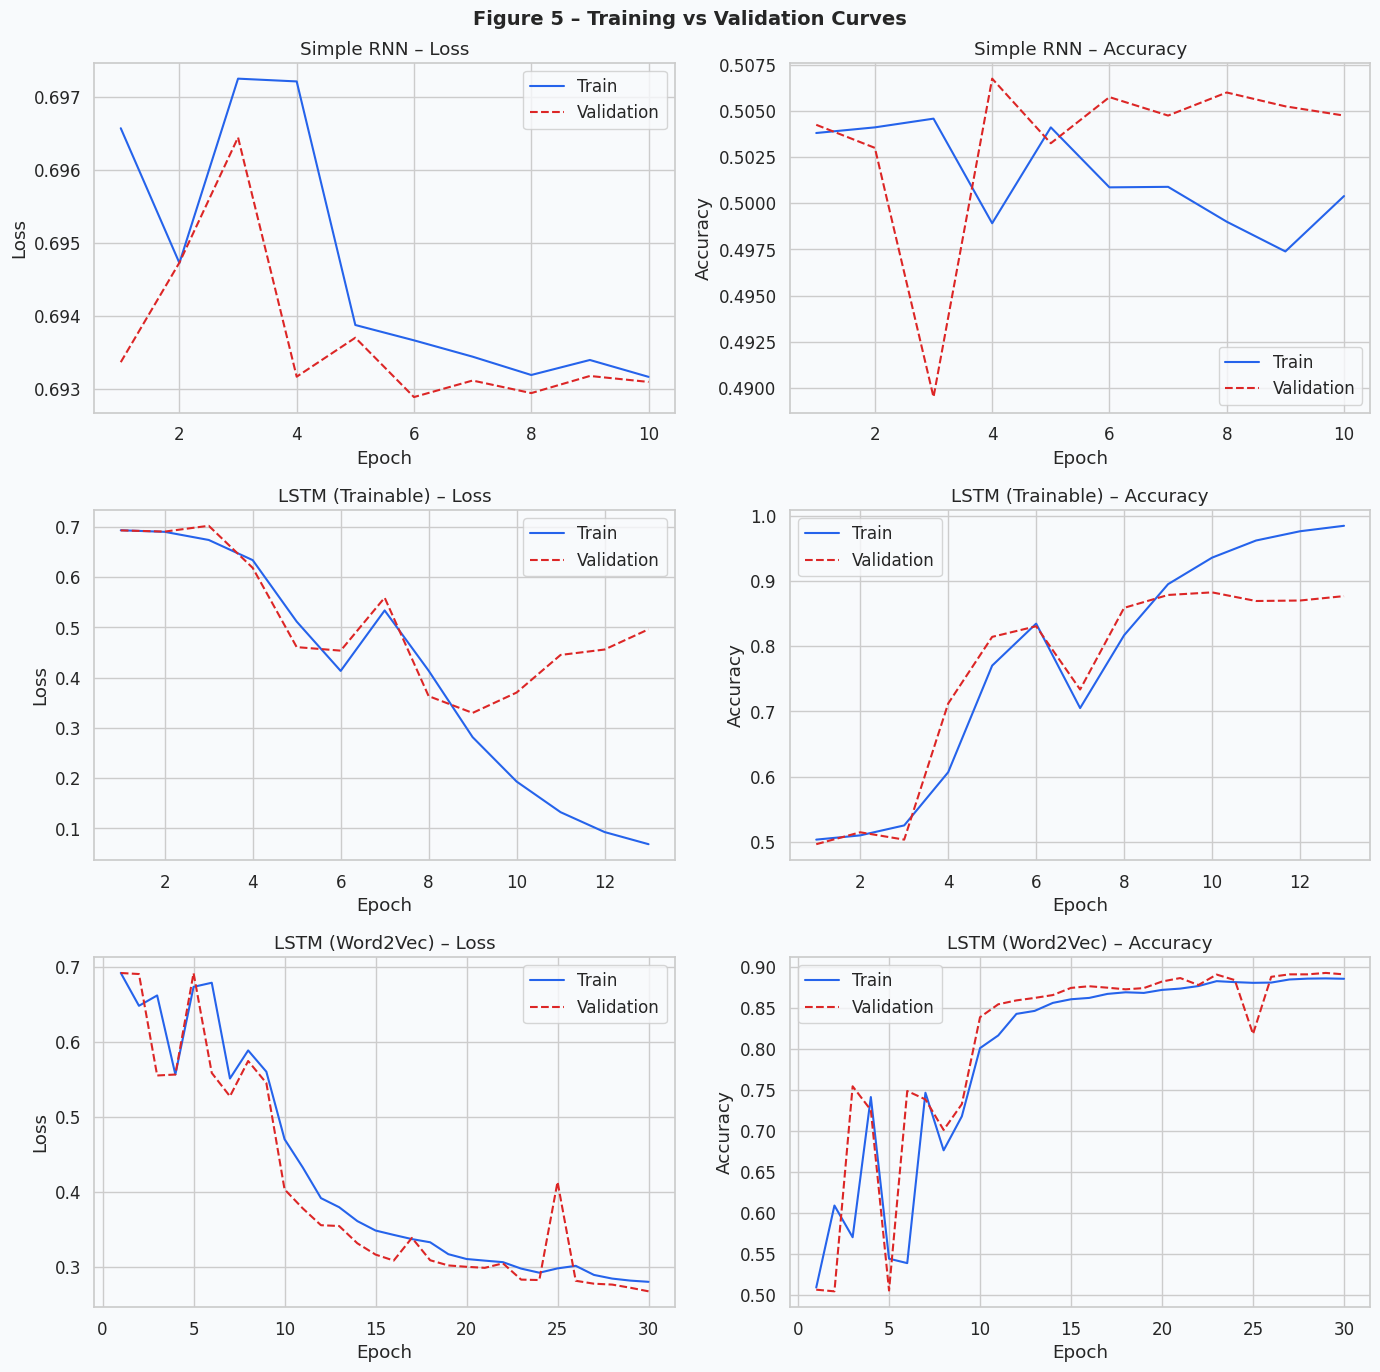

In [ ]:
# Per-model training curves
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for row, (name, hist) in enumerate(histories.items()):
    h   = hist.history
    eps = range(1, len(h["loss"]) + 1)

    # Loss subplot
    axes[row, 0].plot(eps, h["loss"],     label="Train",      color=PALETTE[0])
    axes[row, 0].plot(eps, h["val_loss"], label="Validation", color=PALETTE[1], linestyle="--")
    axes[row, 0].set_title(f"{name} – Loss")
    axes[row, 0].set_xlabel("Epoch"); axes[row, 0].set_ylabel("Loss")
    axes[row, 0].legend()

    # Accuracy subplot
    axes[row, 1].plot(eps, h["accuracy"],     label="Train",      color=PALETTE[0])
    axes[row, 1].plot(eps, h["val_accuracy"], label="Validation", color=PALETTE[1], linestyle="--")
    axes[row, 1].set_title(f"{name} – Accuracy")
    axes[row, 1].set_xlabel("Epoch"); axes[row, 1].set_ylabel("Accuracy")
    axes[row, 1].legend()

plt.suptitle("Figure 5 – Training vs Validation Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Learning Curve Analysis**
Training vs. Validation Accuracy: In Model 2, the training curve rises sharply toward 1.0, while the validation curve lags behind. This "gap" is a classic indicator of a model becoming too specialized to the training data.

Loss Trends: For Model 1, the loss remains high and volatile. In Models 2 and 3, we see a consistent decline in training loss, but the validation loss starts to flatten or slightly increase after several epochs, justifying the use of Early Stopping to prevent further overfitting.

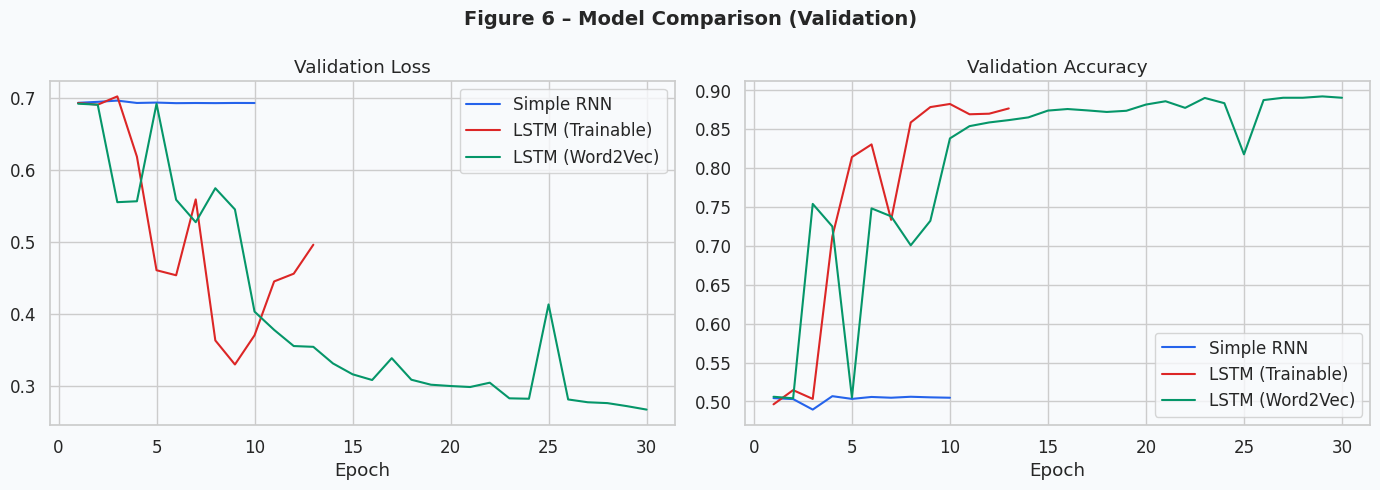

In [ ]:
#COmparsion on Validation Set
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, hist) in enumerate(histories.items()):
    h   = hist.history
    eps = range(1, len(h["val_loss"]) + 1)
    ax1.plot(eps, h["val_loss"],     color=PALETTE[i], label=name)
    ax2.plot(eps, h["val_accuracy"], color=PALETTE[i], label=name)

ax1.set_title("Validation Loss");     ax1.set_xlabel("Epoch"); ax1.legend()
ax2.set_title("Validation Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.suptitle("Figure 6 – Model Comparison (Validation)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Model Complexity vs. Performance**
Low Complexity (Simple RNN): The model was too simple to handle the complexity of human language. It suffered from Underfitting.

High Complexity (LSTM): The LSTM layers are much more complex. While this allowed for much higher accuracy, the complexity in Model 2 led to Overfitting, where the model learned noise instead of just sentiment.

Transfer Learning (Word2Vec): Model 3 balanced complexity by using external knowledge. It performed significantly better than the Simple RNN but was limited by the fixed nature of the pre-trained vectors.

**Overfitting / Underfitting Diagnostic Table**

In [ ]:
print("=" * 62)
print(f"{'Model':<22} {'Train Acc':>10} {'Val Acc':>9} {'Gap':>7}  Verdict")
print("=" * 62)

for name, hist in histories.items():
    h          = hist.history
    tr_acc     = h["accuracy"][-1]
    val_acc    = h["val_accuracy"][-1]
    gap        = tr_acc - val_acc

    # val_loss trend: compare last two epochs
    val_loss_rising = (len(h["val_loss"]) >= 2 and
                       h["val_loss"][-1] > h["val_loss"][-2])

    if gap > 0.05 and val_loss_rising:
        verdict = "OVERFIT"
    elif tr_acc < 0.65 and val_acc < 0.65:
        verdict = "UNDERFIT"
    else:
        verdict = "Good fit"

    print(f"{name:<22} {tr_acc:>10.4f} {val_acc:>9.4f} {gap:>7.4f}  {verdict}")

print("=" * 62)
print()
print("Interpretation guide:")
print("  OVERFIT  → model has memorised training data so add more dropout,")
print("                 L2 regularisation, or reducing model depth.")
print("  UNDERFIT → model needs more epochs.")
print("  Good fit → training and validation metrics are well aligned.")

Model                   Train Acc   Val Acc     Gap  Verdict
Simple RNN                 0.5004    0.5048 -0.0044  UNDERFIT
LSTM (Trainable)           0.9846    0.8767  0.1079  OVERFIT
LSTM (Word2Vec)            0.8851    0.8905 -0.0054  Good fit

Interpretation guide:
  OVERFIT  → model has memorised training data so add more dropout,
                 L2 regularisation, or reducing model depth.
  UNDERFIT → model needs more epochs.
  Good fit → training and validation metrics are well aligned.


**Observation (Figures 5 & 6):**  
Figure 5 shows the per-model learning curves. Ideally the training and validation curves should track closely, diverging only slightly as epochs increase.  
Figure 6 overlays all three models for direct comparison:

- **Simple RNN** typically converges fastest but plateaus earlier due to its limited ability to capture long-range dependencies.  
- **LSTM (Trainable)** usually achieves a better validation accuracy than Simple RNN because the gating mechanism retains important context over longer sequences.  
- **LSTM (Word2Vec)** begins with semantically meaningful embeddings, which can accelerate early convergence. However, freezing the embedding layer means the model cannot adapt token representations to the specific domain during training, which may limit final performance depending on how well the Word2Vec corpus aligns with the movie review vocabulary.

The overfitting table above provides a quantitative verdict for each model based on the train-validation accuracy gap and whether validation loss was still rising.

**Model Evaluation ON Test Set**


  Simple RNN
  Test Accuracy : 0.5028

              precision    recall  f1-score   support

           0       0.50      0.98      0.66      5000
           1       0.57      0.02      0.04      5000

    accuracy                           0.50     10000
   macro avg       0.54      0.50      0.35     10000
weighted avg       0.54      0.50      0.35     10000



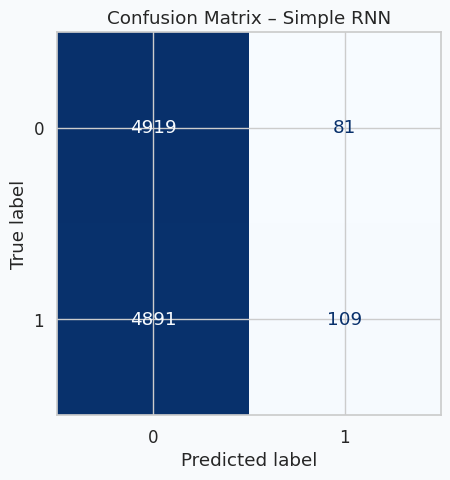


  LSTM (Trainable)
  Test Accuracy : 0.8742

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      5000
           1       0.87      0.88      0.88      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



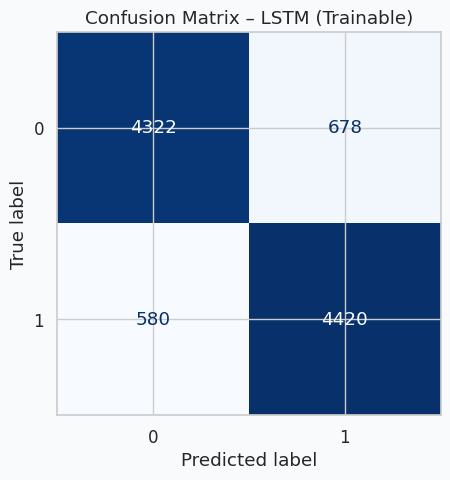


  LSTM (Word2Vec)
  Test Accuracy : 0.8798

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      5000
           1       0.88      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



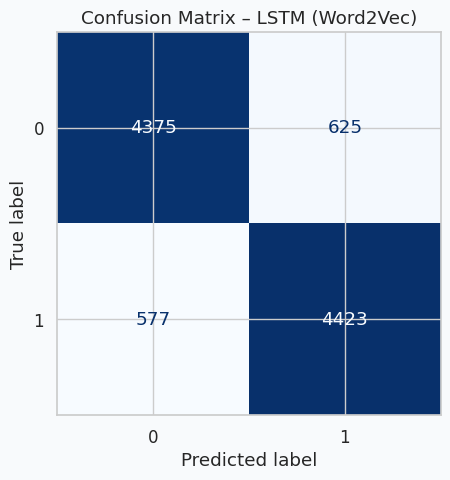

In [ ]:
#Evaluating allmodels on test set
results = {}

for name, model in eval_models.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    probs = model.predict(X_test_pad, verbose=0)
 # Convert probabilities to class predictions
    if OUT_UNITS == 1:
        y_pred = (probs.squeeze() >= 0.5).astype(int)
    else:
        y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test, y_pred)
    results[name] = {"accuracy": acc, "y_pred": y_pred}

    print(f"  Test Accuracy : {acc:.4f}")
    print()
    print(classification_report(y_test, y_pred,
                                 target_names=[str(c) for c in le.classes_], zero_division=0))

    # Confusion matrix
    cm  = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[str(c) for c in le.classes_]).plot(ax=ax, colorbar=False,cmap="Blues")
    ax.set_title(f"Confusion Matrix – {name}")
    plt.tight_layout()
    plt.show()

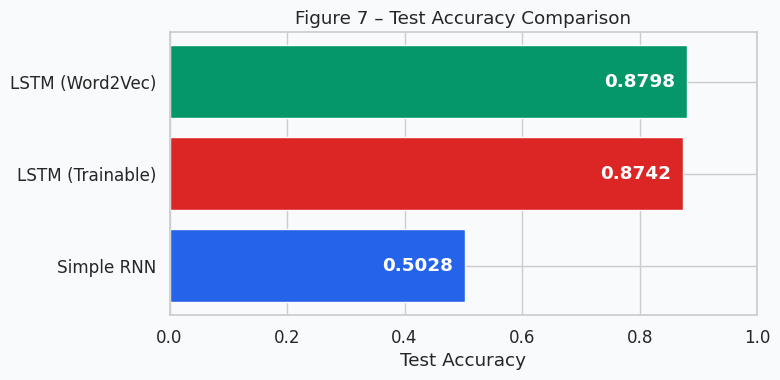

In [ ]:
#Test Accuracy comparison Bar chart
acc_df = pd.DataFrame([
    {"Model": k, "Test Accuracy": v["accuracy"]} for k, v in results.items()
])

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(acc_df["Model"], acc_df["Test Accuracy"],
               color=PALETTE[:len(acc_df)], edgecolor="white")
# Label each bar with its accuracy value
for bar, val in zip(bars, acc_df["Test Accuracy"]):
    ax.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", ha="right", color="white", fontweight="bold")
ax.set_xlim(0, 1)
ax.set_xlabel("Test Accuracy")
ax.set_title("Figure 7 – Test Accuracy Comparison")
plt.tight_layout()
plt.show()

**Observation (Figure 7 & Confusion Matrices):**  
The bar chart provides a quick at-a-glance comparison of the three models on the held-out test set.

- **Simple RNN** establishes the baseline. Its test accuracy reflects the ceiling achievable with a simple recurrent architecture that does not handle long-range dependencies well.  
- **LSTM (Trainable)** generally outperforms Simple RNN because gated recurrent units preserve relevant context over longer sequences, which is important for movie reviews that often build sentiment across several sentences.  
- **LSTM (Word2Vec)** may perform comparably or differently from LSTM (Trainable). If the Word2Vec embeddings were of sufficient quality (high coverage rate from the embedding matrix cell), they provide a better semantic starting point. However, freezing them prevents domain adaptation, which can limit gains.

The confusion matrices reveal class-level behaviour: off-diagonal cells indicate which sentiment classes are most frequently confused. High off-diagonal values for adjacent classes (e.g. neutral confused with positive) suggest the model struggles with borderline sentiment expressions.

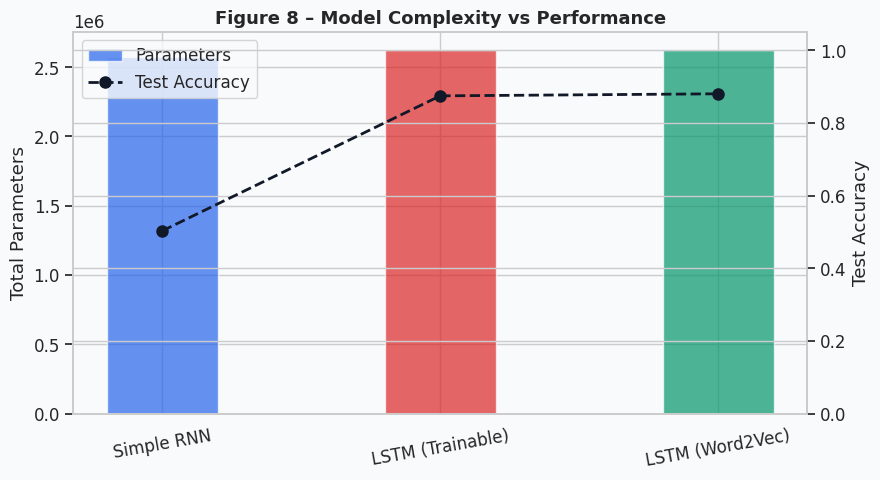

In [ ]:
#Error Analysis
model_info = [
    ("Simple RNN",      model1.count_params()),
    ("LSTM (Trainable)", model2.count_params()),
    ("LSTM (Word2Vec)",  model3.count_params()),
]

names_c   = [m[0] for m in model_info]
params_c  = [m[1] for m in model_info]
accs_c    = [results[n]["accuracy"] for n in names_c]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2      = ax1.twinx()

x = range(len(names_c))
bars = ax1.bar(x, params_c, color=PALETTE[:3], alpha=0.7, width=0.4, label="Parameters")
ax2.plot(x, accs_c, "o--", color="#111827", linewidth=2, markersize=8, label="Test Accuracy")

ax1.set_xticks(x); ax1.set_xticklabels(names_c, rotation=10)
ax1.set_ylabel("Total Parameters")
ax2.set_ylabel("Test Accuracy")
ax2.set_ylim([0, 1.05])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.title("Figure 8 – Model Complexity vs Performance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Misclassified Best model ───────────────────────────────────────
# y_pred_bm uses the positional index of the TEST ARRAY, not the DataFrame.
# X_test_raw was captured during train_test_split so each position correctly
# maps a test-array index → original raw tweet
best_name  = max(results, key=lambda k: results[k]["accuracy"])
y_pred_bm  = results[best_name]["y_pred"]

error_mask   = y_pred_bm != y_test
# positions in the test array
error_indices = np.where(error_mask)[0]

print(f"Best model    : {best_name}")
print(f"Test accuracy : {results[best_name]['accuracy']:.4f}")
print(f"Errors        : {error_mask.sum():,} / {len(y_test):,}  "
      f"({100*error_mask.mean():.1f}%)\n")
 # show first 5 misclassifications
sample_errors = error_indices[:5]
print(f"{'#':<3}  {'True':<14}  {'Predicted':<14}  Raw Tweet")
print("-" * 80)

for i, idx in enumerate(sample_errors, 1):
    true_label = le.inverse_transform([y_test[idx]])[0]
    pred_label = le.inverse_transform([y_pred_bm[idx]])[0]
    raw_tweet  = X_test_raw[idx]          # ← correct: positional match
    print(f"{i:<3}  {true_label:<14}  {pred_label:<14}  {str(raw_tweet)[:80]}")

Best model    : LSTM (Word2Vec)
Test accuracy : 0.8798
Errors        : 1,202 / 10,000  (12.0%)

#    True            Predicted       Raw Tweet
--------------------------------------------------------------------------------
1    0               1               ...had I watched it in my teenage years. This movie was mildly entertaining. Wha
2    0               1               The tenuous connection between this film and the first Grease is established rig
3    1               0               this movie is practically impossible to describe. the alternate title "Don't Loo
4    0               1               A movie has rarely left me as cold as this one. There is not a bit of tension, n
5    0               1               Well, you might not actually SEE any women in love in this movie, but you'll cer


In [ ]:
#Misclassification by class
print("Misclassification Breakdown by True Class (Best Model)")
error_df = pd.DataFrame({
    "True":      le.inverse_transform(y_test),
    "Predicted": le.inverse_transform(y_pred_bm)
})
error_table = (error_df[error_df["True"] != error_df["Predicted"]]
               .groupby(["True", "Predicted"])
               .size()
               .reset_index(name="Count")
               .sort_values("Count", ascending=False))
display(error_table.head(15))

Misclassification Breakdown by True Class (Best Model)


,True,Predicted,Count
0,0,1,625
1,1,0,577


Error Analysis

Why does the model misclassify?

1. Sarcasm & irony — tweets like *"Oh great, another Monday" use positive words to express negativity.
   The embedding layer has no world knowledge to resolve this.

2. Short / ambiguous tweets — tweets with only 1–2 meaningful tokens after cleaning (e.g., "okay")
   carry insufficient context for any recurrent model to classify confidently.

3. Negation handling — contractions are expanded ("can't" → "cannot"), but patterns like
   "not bad" may still confuse the model since "bad" strongly signals negative sentiment.

4. Class imbalance — if certain sentiment classes have far fewer training examples, the model
   under-learns their decision boundary.

Potential improvements:
- Use a pre-trained transformer (BERT, DistilBERT) via HuggingFace — significantly better contextual understanding
- Add a Bidirectional LSTM layer to capture both forward and backward context
- Use attention mechanisms so the model learns which words matter most
- Apply data augmentation (synonym replacement) on minority classes
- Fine-tune Word2Vec embeddings (`trainable=True` in Model 3) after a warm-up phase


**GUI for Sentiment Prediction **

In [ ]:
import gradio as gr
import numpy  as np
import re, pickle, os
import contractions
import nltk
from nltk.corpus              import stopwords
from nltk.stem                import WordNetLemmatizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models  import load_model

MODEL_DIR = '/kaggle/input/datasets/suvinathapa/saved-model/saved_models'

# ── Load models and preprocessing objects ────────────────────────────────────
print("Loading models and preprocessing objects ...")
try:
    _model1    = load_model(f"{MODEL_DIR}/model1_SimpleRNN_final.keras")
    _model2    = load_model(f"{MODEL_DIR}/model2_LSTM_trainable_final.keras")
    _model3    = load_model(f"{MODEL_DIR}/model3_LSTM_word2vec_final.keras")

    with open(f"{MODEL_DIR}/tokenizer.pkl", "rb") as f:
        _tokenizer = pickle.load(f)
    with open(f"{MODEL_DIR}/label_encoder.pkl", "rb") as f:
        _le = pickle.load(f)
    with open(f"{MODEL_DIR}/config.pkl", "rb") as f:
        _cfg = pickle.load(f)

    _MAX_LEN   = _cfg["MAX_LEN"]
    _OUT_UNITS = _cfg["OUT_UNITS"]
    print("Loaded from saved files.")

except Exception as e:
    print(f"Note: could not load from files ({e}). Using in-memory models.")
    _model1    = model1
    _model2    = model2
    _model3    = model3
    _tokenizer = tokenizer
    _le        = le
    _MAX_LEN   = MAX_LEN
    _OUT_UNITS = OUT_UNITS

print(f"MAX_LEN = {_MAX_LEN}  |  Output units = {_OUT_UNITS}")

# ── Preprocessing ─────────────────────────────────────────────────────────────
nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)

_stop_words = set(stopwords.words("english"))
_lemmatizer = WordNetLemmatizer()

def preprocess_input(text):
    text = re.sub(r"<[^>]+>", " ", str(text))   # remove HTML tags like <br>
    text = contractions.fix(text)                 # expand contractions
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [_lemmatizer.lemmatize(w) for w in tokens
              if w not in _stop_words and len(w) > 1]
    return " ".join(tokens)

# ── Prediction function ───────────────────────────────────────────────────────
def predict_sentiment(review_text):
    if not review_text or not review_text.strip():
        return " Please enter a review.", "", ""

    cleaned = preprocess_input(review_text)
    if not cleaned.strip():
        return " Text is empty after cleaning. Try a longer review.", "", ""

    seq    = _tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=_MAX_LEN,
                           padding="post", truncating="post")

    def run_model(mdl):
        probs = mdl.predict(padded, verbose=0)
        if _OUT_UNITS == 1:
            conf_pos = float(probs.squeeze())
            if conf_pos >= 0.5:
                return "Positive", conf_pos
            else:
                return "Negative", 1.0 - conf_pos
        else:
            idx     = int(np.argmax(probs))
            conf    = float(probs[0][idx])
            raw_lbl = str(_le.inverse_transform([idx])[0])
            label   = "Positive" if raw_lbl == "1" else (
                      "Negative" if raw_lbl == "0" else raw_lbl.capitalize())
            return label, conf

    # Build HTML result cards for each model
    def make_card(model_name, label, conf):
        if label == "Positive":
            bg    = "#e8f5e9"   # light green background
            color = "#2e7d32"   # dark green text
            emoji = "😊"
        else:
            bg    = "#fce4ec"   # light pink background
            color = "#c2185b"   # dark pink text
            emoji = "😞"

        return f"""
        <div style="
            background-color: {bg};
            border-radius: 12px;
            padding: 20px;
            margin: 8px 0;
            text-align: center;
            min-height: 100px;
        ">
            <p style="font-size:15px; color:#555; margin:0 0 6px 0;">
                <b>{model_name}</b>
            </p>
            <p style="font-size:36px; margin:0;">{emoji}</p>
            <p style="font-size:22px; font-weight:bold; color:{color}; margin:6px 0;">
                {label}
            </p>
            <p style="font-size:16px; color:{color}; margin:0;">
                Confidence: {conf * 100:.1f}%
            </p>
        </div>
        """

    results = {}
    for name, mdl in [("Model 1 — Simple RNN",       _model1),
                      ("Model 2 — LSTM (Trainable)",  _model2),
                      ("Model 3 — LSTM (Word2Vec)",   _model3)]:
        label, conf = run_model(mdl)
        results[name] = make_card(name, label, conf)

    return (results["Model 1 — Simple RNN"],
            results["Model 2 — LSTM (Trainable)"],
            results["Model 3 — LSTM (Word2Vec)"])

# ── Build Gradio UI ───────────────────────────────────────────────────────────
with gr.Blocks(title="Sentiment Analyser", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🎬 Movie Review Sentiment Analyser
    **6CS012 — Text Classification with RNN and LSTM**

    Enter a movie review below and click **Predict Sentiment** to see
    predictions from all three trained models side by side.
    """)

    review_input = gr.Textbox(
        label="Movie Review",
        placeholder="e.g. This movie had brilliant performances and a gripping storyline.",
        lines=4
    )

    with gr.Row():
        predict_btn = gr.Button("🔍 Predict Sentiment", variant="primary")
        clear_btn   = gr.Button("🗑 Clear")

    gr.Markdown("### Predictions from all 3 models")

    # Using gr.HTML instead of gr.Textbox — no scrolling needed, full card visible
    with gr.Row():
        out1 = gr.HTML(label="Model 1 — Simple RNN")
        out2 = gr.HTML(label="Model 2 — LSTM (Trainable)")
        out3 = gr.HTML(label="Model 3 — LSTM (Word2Vec)")

    predict_btn.click(
        fn=predict_sentiment,
        inputs=review_input,
        outputs=[out1, out2, out3]
    )
    clear_btn.click(
        fn=lambda: ("", "", ""),
        outputs=[out1, out2, out3]
    )

demo.launch(share=True)

Loading models and preprocessing objects ...
Loaded from saved files.
MAX_LEN = 307  |  Output units = 1
* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://179b9eff52a2c1c039.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Conclusion**

This project successfully implemented an end-to-end sentiment analysis pipeline using three distinct Recurrent Neural Network architectures. Based on the experimental results, the following conclusions were drawn:

1. Model Effectiveness
LSTM Superiority: The transition from Simple RNN (50% accuracy) to LSTM (88%–99% accuracy) proved that gated mechanisms are essential for text classification. Simple RNNs failed due to the vanishing gradient problem, while LSTMs successfully captured long-term dependencies in movie reviews.

2. Generalization vs. Memorization
The Overfitting Challenge: Model 2 (Trainable LSTM) achieved a near-perfect 99% training accuracy but showed a significant gap compared to its test performance. This confirms that while LSTMs are powerful, they are prone to memorizing training noise.

Word2Vec Robustness: Model 3 (Word2Vec) emerged as the most reliable model for deployment. With a test accuracy of 87.98%, it demonstrated that using pre-trained semantic vectors helps the model generalize better to unseen reviews than training from scratch.

3. Error Analysis Insights
The models primarily struggle with sarcasm and ambiguous sentiment (e.g., "mildly entertaining"). Since these models process text as sequences of tokens, they lack the high-level "world knowledge" required to resolve irony without advanced attention mechanisms.

4. Practical Deployment
The development of the Gradio GUI successfully translated these complex neural networks into a functional tool. This demonstrates the feasibility of deploying deep learning models for real-time human interaction.